In [1]:
!pip install tensorflow matplotlib scikit-learn


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install tensorflow


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install keras


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
!pip install tensorflow --upgrade --quiet



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
#✅ Import Libraries

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import VGG16, ResNet50, MobileNetV2
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np
import os


In [6]:
#✅ Set Directories

test_dir = r'C:\Users\VARSHA\OneDrive\Desktop\cnn project\test'
train_dir = r'C:\Users\VARSHA\OneDrive\Desktop\cnn project\train'
val_dir   = r'C:\Users\VARSHA\OneDrive\Desktop\cnn project\val'


In [7]:
#✅ Image Data Generators

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)


Found 4536 images belonging to 4 classes.
Found 1242 images belonging to 4 classes.
Found 1245 images belonging to 4 classes.


In [8]:
#✅ 1️⃣ Build a Simple Custom CNN

def build_custom_cnn(input_shape, num_classes):
    model = Sequential([
        tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        tf.keras.layers.MaxPooling2D(2,2),
        
        tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        
        tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
        tf.keras.layers.MaxPooling2D(2,2),
        
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(num_classes, activation='softmax')
    ])
    return model

custom_cnn = build_custom_cnn(input_shape=(224,224,3), num_classes=4)
custom_cnn.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])
custom_cnn.summary()


C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,476 (42.61 MB)

 Trainable params: 11,169,476 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
#✅ 2️⃣ Build Transfer Learning Models

def build_transfer_model(base_model, num_classes):
    for layer in base_model.layers:
        layer.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.5)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model

# VGG16
vgg_base = VGG16(weights='imagenet', include_top=False, input_shape=(224,224,3))
vgg_model = build_transfer_model(vgg_base, 4)
vgg_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# ResNet50
resnet_base = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
resnet_model = build_transfer_model(resnet_base, 4)
resnet_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])

# MobileNetV2
mobile_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224,224,3))
mobile_model = build_transfer_model(mobile_base, 4)
mobile_model.compile(optimizer=Adam(1e-4), loss='categorical_crossentropy', metrics=['accuracy'])


In [10]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [11]:
checkpoint_cb = ModelCheckpoint(
    'best_model.h5',           # File name for saved model
    save_best_only=True,       # Only saves best model
    monitor='val_loss',        # Monitors validation loss
    mode='min'
)

earlystop_cb = EarlyStopping(
    monitor='val_loss',
    patience=5,                # Stop if no improvement for 5 epochs
    restore_best_weights=True
)

In [ ]:
#✅ 3️⃣ Train Each Model
#Train Custom CNN

history_cnn = custom_cnn.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        ModelCheckpoint('custom_cnn_best.h5', save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 845ms/step - accuracy: 0.4868 - loss: 1.1119

142/142 ━━━━━━━━━━━━━━━━━━━━ 129s 910ms/step - accuracy: 0.4872 - loss: 1.1112 - val_accuracy: 0.7520 - val_loss: 0.6792
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 737ms/step - accuracy: 0.6530 - loss: 0.8397

142/142 ━━━━━━━━━━━━━━━━━━━━ 112s 785ms/step - accuracy: 0.6530 - loss: 0.8395 - val_accuracy: 0.7858 - val_loss: 0.6003
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 747ms/step - accuracy: 0.6943 - loss: 0.7612

142/142 ━━━━━━━━━━━━━━━━━━━━ 113s 796ms/step - accuracy: 0.6944 - loss: 0.7611 - val_accuracy: 0.7939 - val_loss: 0.5481
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 790ms/step - accuracy: 0.7266 - loss: 0.6975

142/142 ━━━━━━━━━━━━━━━━━━━━ 119s 841ms/step - accuracy: 0.7267 - loss: 0.6973 - val_accuracy: 0.8060 - val_loss: 0.4841
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 116s 818ms/step - accuracy: 0.7402 - loss: 0.6679 - val_accuracy: 0.8060 - val_loss: 0.5136
Epoch 6/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 755ms/step - accuracy: 0.7488 - loss: 0.6419

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 111s 782ms/step - accuracy: 0.8248 - loss: 0.4767 - val_accuracy: 0.8462 - val_loss: 0.3596
Epoch 16/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 738ms/step - accuracy: 0.8293 - loss: 0.4421

142/142 ━━━━━━━━━━━━━━━━━━━━ 112s 787ms/step - accuracy: 0.8293 - loss: 0.4421 - val_accuracy: 0.8647 - val_loss: 0.3334
Epoch 17/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 118s 831ms/step - accuracy: 0.8295 - loss: 0.4412 - val_accuracy: 0.8615 - val_loss: 0.3400
Epoch 18/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 808ms/step - accuracy: 0.8308 - loss: 0.4334

142/142 ━━━━━━━━━━━━━━━━━━━━ 123s 865ms/step - accuracy: 0.8308 - loss: 0.4334 - val_accuracy: 0.8720 - val_loss: 0.3108
Epoch 19/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 123s 869ms/step - accuracy: 0.8362 - loss: 0.4091 - val_accuracy: 0.8357 - val_loss: 0.4011
Epoch 20/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 124s 869ms/step - accuracy: 0.8513 - loss: 0.4109 - val_accuracy: 0.8519 - val_loss: 0.3639
Epoch 21/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.8544 - loss: 0.3838 - val_accuracy: 0.8704 - val_loss: 0.3400
Epoch 22/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 807ms/step - accuracy: 0.8468 - loss: 0.3786

142/142 ━━━━━━━━━━━━━━━━━━━━ 122s 858ms/step - accuracy: 0.8468 - loss: 0.3787 - val_accuracy: 0.8824 - val_loss: 0.3053
Epoch 23/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 996ms/step - accuracy: 0.8517 - loss: 0.3772

142/142 ━━━━━━━━━━━━━━━━━━━━ 152s 1s/step - accuracy: 0.8517 - loss: 0.3772 - val_accuracy: 0.8937 - val_loss: 0.2818
Epoch 24/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 218s 2s/step - accuracy: 0.8447 - loss: 0.3811 - val_accuracy: 0.8792 - val_loss: 0.3164
Epoch 25/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 149s 1s/step - accuracy: 0.8613 - loss: 0.3687 - val_accuracy: 0.8849 - val_loss: 0.3053
Epoch 26/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 133s 936ms/step - accuracy: 0.8560 - loss: 0.3553 - val_accuracy: 0.8913 - val_loss: 0.2925
Epoch 27/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 132s 927ms/step - accuracy: 0.8686 - loss: 0.3360 - val_accuracy: 0.8800 - val_loss: 0.3032
Epoch 28/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 132s 925ms/step - accuracy: 0.8690 - loss: 0.3370 - val_accuracy: 0.8688 - val_loss: 0.3334


In [13]:
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, precision_recall_curve,average_precision_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [14]:
def evaluate_model(y_true, y_pred, y_probs, class_labels):
    # Classification Report
    print("\n Classification Report:\n")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_labels, yticklabels=class_labels, cmap="Blues")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # ROC Curve (macro average)
    if len(class_labels) > 2:
        from sklearn.preprocessing import label_binarize
        y_true_bin = label_binarize(y_true, classes=list(range(len(class_labels))))
        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        for i in range(len(class_labels)):
            fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])

        # Plot macro-average ROC
        plt.figure()
        for i in range(len(class_labels)):
            plt.plot(fpr[i], tpr[i], label=f'{class_labels[i]} (AUC = {roc_auc[i]:.2f})')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()
    else:
        fpr, tpr, _ = roc_curve(y_true, y_probs[:, 1])
        roc_auc = auc(fpr, tpr)
        plt.figure()
        plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
        plt.plot([0, 1], [0, 1], 'k--')
        plt.xlabel('FPR')
        plt.ylabel('TPR')
        plt.title('ROC Curve')
        plt.legend()
        plt.show()

    # Precision-Recall Curve
    plt.figure()
    for i in range(len(class_labels)):
        precision, recall, _ = precision_recall_curve(label_binarize(y_true, classes=list(range(len(class_labels))))[:, i], y_probs[:, i])
        plt.plot(recall, precision, label=f"{class_labels[i]}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision-Recall Curve")
    plt.legend()
    plt.show()

In [15]:
from tensorflow.keras.models import load_model

model = load_model('custom_cnn_best.h5')

In [16]:
test_datagen = ImageDataGenerator(rescale=1./255)
test_dataset = test_datagen.flow_from_directory(
    directory=r'C:\Users\VARSHA\OneDrive\Desktop\cnn project\test',
    target_size=IMG_SIZE,
    batch_size=1,  # Important for per-sample predictions
    class_mode='categorical',
    shuffle=False
)

Found 1245 images belonging to 4 classes.


In [29]:
loss, accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1245/1245 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.8564 - loss: 0.3503
Test Accuracy: 89.80%


In [30]:
predictions = model.predict(test_dataset, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_dataset.classes

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step



📄 Classification Report:

              precision    recall  f1-score   support

      glioma       0.95      0.76      0.85       244
     healthy       0.94      0.97      0.96       433
  meningioma       0.80      0.81      0.80       256
   pituitary       0.88      0.97      0.93       312

    accuracy                           0.90      1245
   macro avg       0.89      0.88      0.88      1245
weighted avg       0.90      0.90      0.90      1245



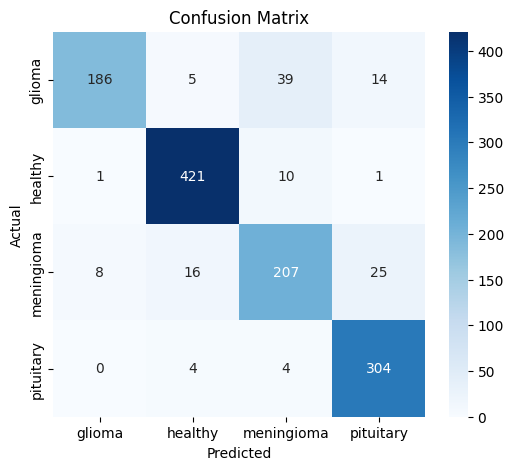

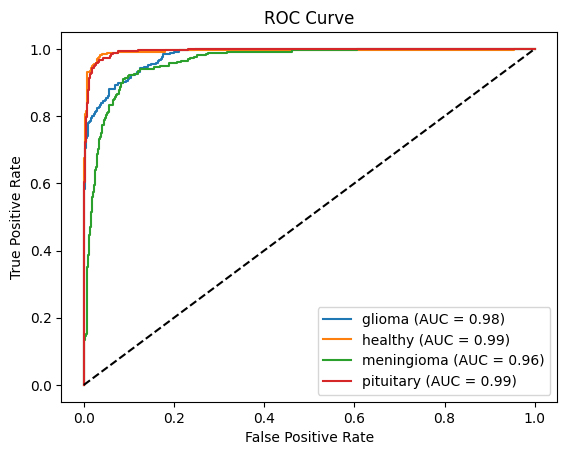

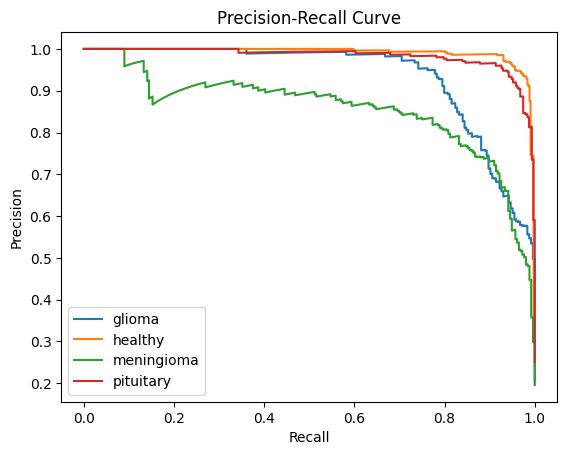

In [31]:
evaluate_model(true_classes, predicted_classes, predictions, list(test_dataset.class_indices.keys()))

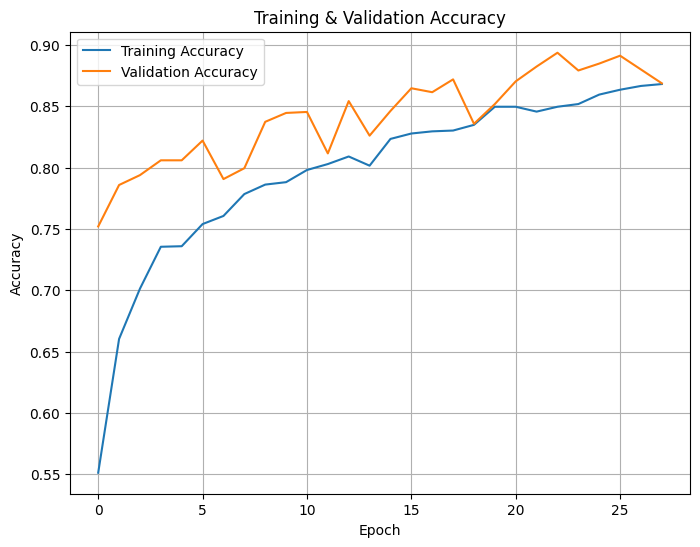

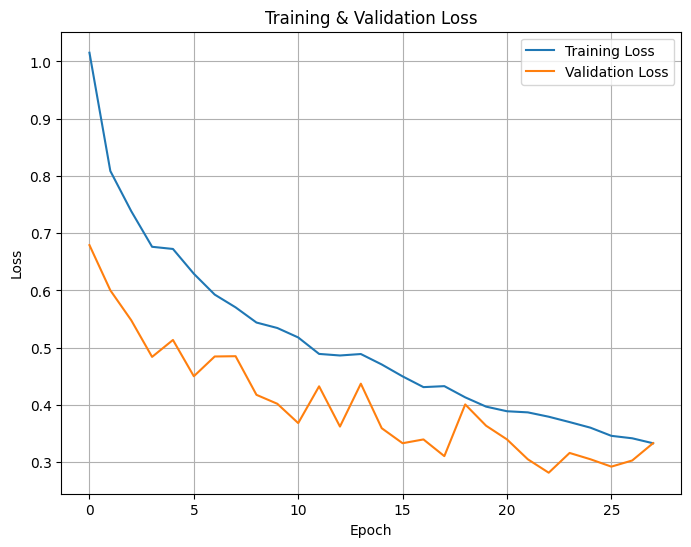

In [33]:
import matplotlib.pyplot as plt


# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [14]:
#Train VGG16

history_vgg = vgg_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        ModelCheckpoint('vgg16_best.h5', save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.2707 - loss: 1.5667

142/142 ━━━━━━━━━━━━━━━━━━━━ 733s 5s/step - accuracy: 0.2709 - loss: 1.5659 - val_accuracy: 0.6224 - val_loss: 1.2298
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.4028 - loss: 1.2820

142/142 ━━━━━━━━━━━━━━━━━━━━ 797s 6s/step - accuracy: 0.4031 - loss: 1.2817 - val_accuracy: 0.7085 - val_loss: 1.1078
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5338 - loss: 1.1521

142/142 ━━━━━━━━━━━━━━━━━━━━ 791s 6s/step - accuracy: 0.5339 - loss: 1.1519 - val_accuracy: 0.7206 - val_loss: 1.0196
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6174 - loss: 1.0400

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 770s 5s/step - accuracy: 0.7854 - loss: 0.5852 - val_accuracy: 0.8221 - val_loss: 0.4916
Epoch 25/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7873 - loss: 0.5774

142/142 ━━━━━━━━━━━━━━━━━━━━ 787s 6s/step - accuracy: 0.7874 - loss: 0.5774 - val_accuracy: 0.8221 - val_loss: 0.4890
Epoch 26/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7999 - loss: 0.5690

142/142 ━━━━━━━━━━━━━━━━━━━━ 792s 6s/step - accuracy: 0.7999 - loss: 0.5690 - val_accuracy: 0.8245 - val_loss: 0.4834
Epoch 27/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8087 - loss: 0.5451

142/142 ━━━━━━━━━━━━━━━━━━━━ 786s 6s/step - accuracy: 0.8087 - loss: 0.5452 - val_accuracy: 0.8261 - val_loss: 0.4754
Epoch 28/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 781s 6s/step - accuracy: 0.8012 - loss: 0.5559 - val_accuracy: 0.8245 - val_loss: 0.4780
Epoch 29/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7982 - loss: 0.5499

142/142 ━━━━━━━━━━━━━━━━━━━━ 778s 5s/step - accuracy: 0.7982 - loss: 0.5499 - val_accuracy: 0.8333 - val_loss: 0.4641
Epoch 30/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 780s 5s/step - accuracy: 0.7969 - loss: 0.5618 - val_accuracy: 0.8237 - val_loss: 0.4652


In [15]:
from tensorflow.keras.models import load_model

model = load_model('vgg16_best.h5')

In [22]:
loss, accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1245/1245 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - accuracy: 0.8564 - loss: 0.3503
Test Accuracy: 89.80%


In [23]:
predictions = model.predict(test_dataset, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_dataset.classes

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 12s 10ms/step



 Classification Report:

              precision    recall  f1-score   support

      glioma       0.95      0.76      0.85       244
     healthy       0.94      0.97      0.96       433
  meningioma       0.80      0.81      0.80       256
   pituitary       0.88      0.97      0.93       312

    accuracy                           0.90      1245
   macro avg       0.89      0.88      0.88      1245
weighted avg       0.90      0.90      0.90      1245



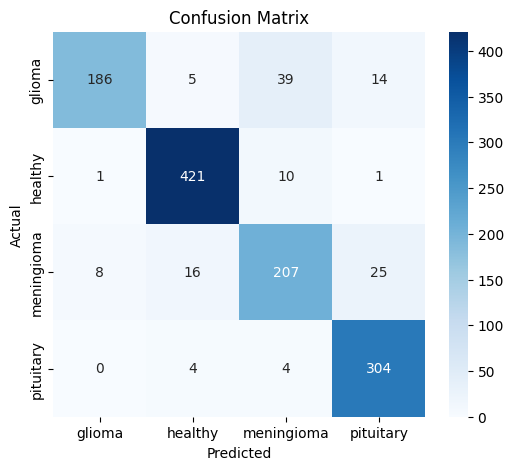

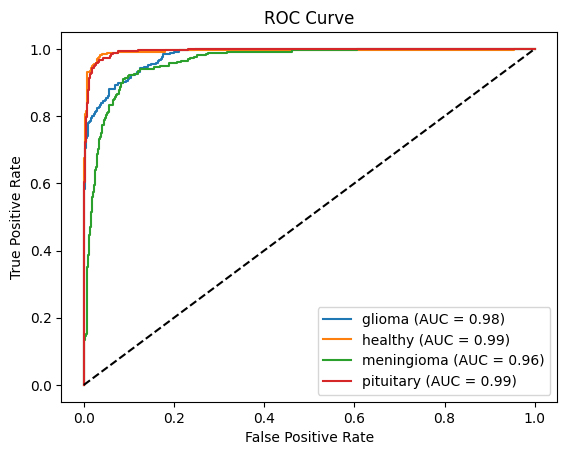

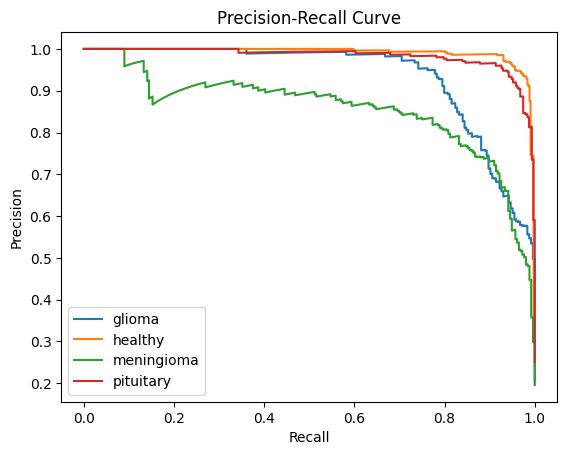

In [24]:
evaluate_model(true_classes, predicted_classes, predictions, list(test_dataset.class_indices.keys()))

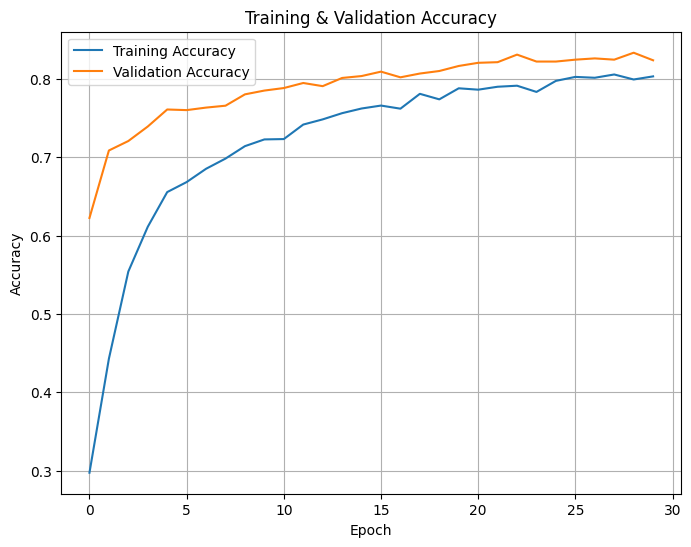

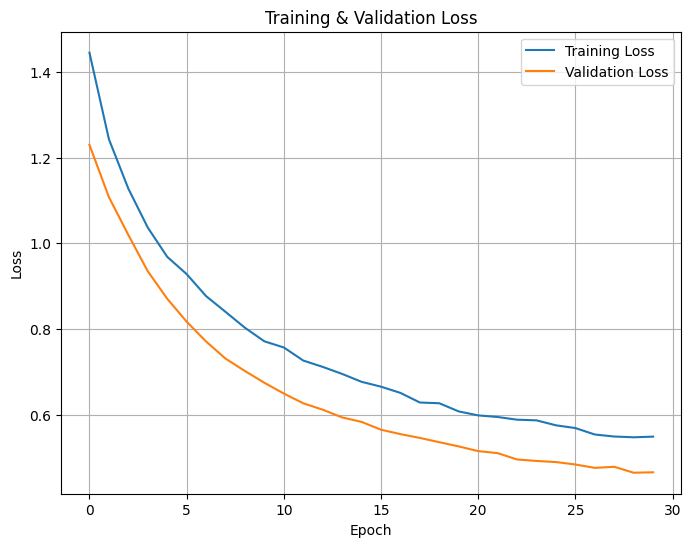

In [26]:
import matplotlib.pyplot as plt


# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history_vgg.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(history_vgg.history['loss'], label='Training Loss')
plt.plot(history_vgg.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
#Train ResNet50

history_resnet = resnet_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        ModelCheckpoint('resnet50_best.h5', save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.2718 - loss: 1.5397

142/142 ━━━━━━━━━━━━━━━━━━━━ 290s 2s/step - accuracy: 0.2720 - loss: 1.5390 - val_accuracy: 0.5580 - val_loss: 1.1871
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4038 - loss: 1.2586

142/142 ━━━━━━━━━━━━━━━━━━━━ 265s 2s/step - accuracy: 0.4039 - loss: 1.2585 - val_accuracy: 0.5499 - val_loss: 1.1219
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4583 - loss: 1.2116

142/142 ━━━━━━━━━━━━━━━━━━━━ 276s 2s/step - accuracy: 0.4584 - loss: 1.2115 - val_accuracy: 0.6176 - val_loss: 1.0711
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4873 - loss: 1.1660

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 272s 2s/step - accuracy: 0.6207 - loss: 0.9236 - val_accuracy: 0.7029 - val_loss: 0.7982
Epoch 27/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6268 - loss: 0.9156

142/142 ━━━━━━━━━━━━━━━━━━━━ 279s 2s/step - accuracy: 0.6267 - loss: 0.9157 - val_accuracy: 0.7174 - val_loss: 0.7907
Epoch 28/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6244 - loss: 0.9170

142/142 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.6243 - loss: 0.9170 - val_accuracy: 0.7166 - val_loss: 0.7781
Epoch 29/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6135 - loss: 0.9255

142/142 ━━━━━━━━━━━━━━━━━━━━ 280s 2s/step - accuracy: 0.6136 - loss: 0.9255 - val_accuracy: 0.7166 - val_loss: 0.7773
Epoch 30/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6277 - loss: 0.8966

142/142 ━━━━━━━━━━━━━━━━━━━━ 271s 2s/step - accuracy: 0.6277 - loss: 0.8968 - val_accuracy: 0.7134 - val_loss: 0.7682


In [17]:
from tensorflow.keras.models import load_model

model = load_model('resnet50_best.h5')

In [18]:
loss, accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

C:\Users\VARSHA\AppData\Roaming\Python\Python311\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1245/1245 ━━━━━━━━━━━━━━━━━━━━ 85s 67ms/step - accuracy: 0.6974 - loss: 0.8015
Test Accuracy: 73.09%


In [19]:
predictions = model.predict(test_dataset, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_dataset.classes

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 88s 70ms/step



 Classification Report:

              precision    recall  f1-score   support

      glioma       0.56      0.61      0.58       244
     healthy       0.91      0.83      0.87       433
  meningioma       0.58      0.50      0.54       256
   pituitary       0.74      0.88      0.80       312

    accuracy                           0.73      1245
   macro avg       0.70      0.70      0.70      1245
weighted avg       0.73      0.73      0.73      1245



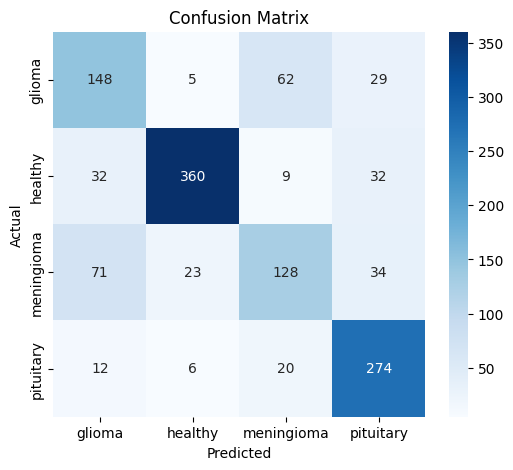

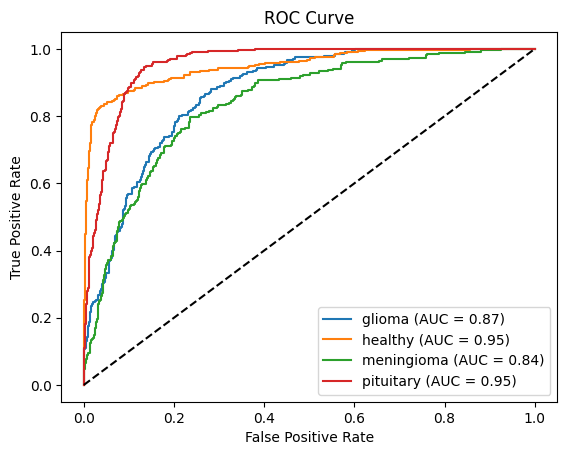

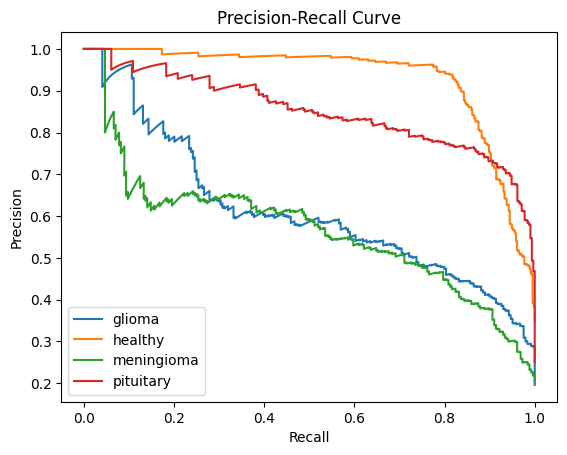

In [20]:
evaluate_model(true_classes, predicted_classes, predictions, list(test_dataset.class_indices.keys()))

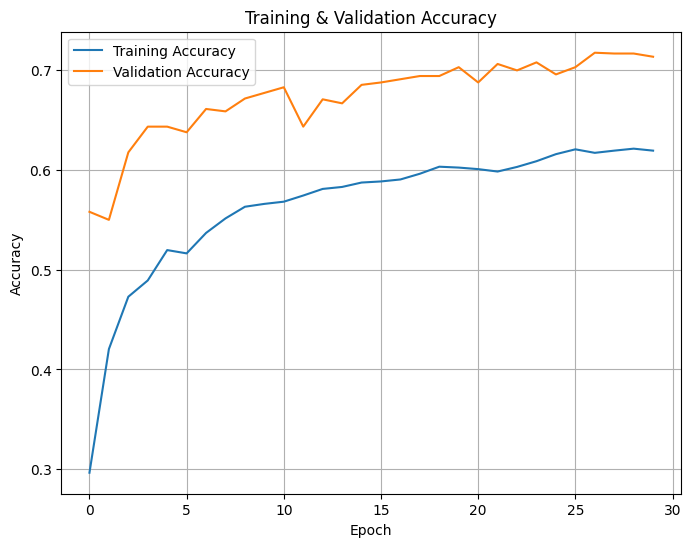

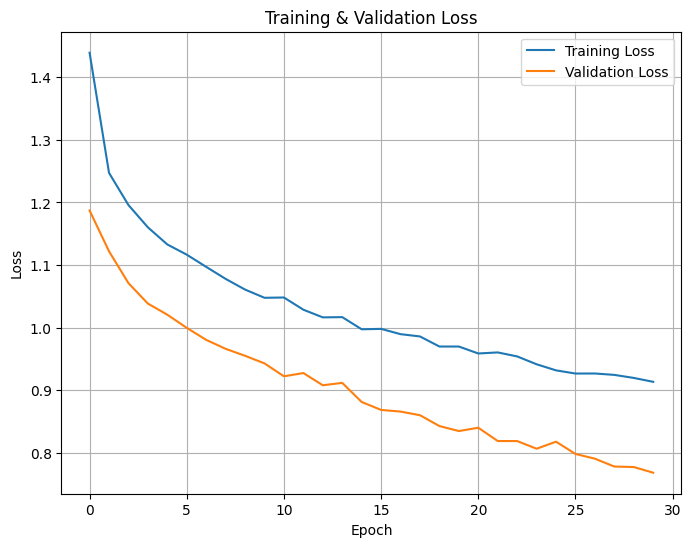

In [21]:
import matplotlib.pyplot as plt


# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history_resnet.history['accuracy'], label='Training Accuracy')
plt.plot(history_resnet.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(history_resnet.history['loss'], label='Training Loss')
plt.plot(history_resnet.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [22]:
#Train MobileNetV2

history_mobile = mobile_model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[
        ModelCheckpoint('mobilenetv2_best.h5', save_best_only=True, monitor='val_loss', mode='min'),
        EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    ]
)

Epoch 1/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 524ms/step - accuracy: 0.4431 - loss: 1.2769

142/142 ━━━━━━━━━━━━━━━━━━━━ 91s 621ms/step - accuracy: 0.4439 - loss: 1.2752 - val_accuracy: 0.7649 - val_loss: 0.6405
Epoch 2/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 500ms/step - accuracy: 0.7317 - loss: 0.6944

142/142 ━━━━━━━━━━━━━━━━━━━━ 84s 588ms/step - accuracy: 0.7319 - loss: 0.6941 - val_accuracy: 0.7794 - val_loss: 0.5436
Epoch 3/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 510ms/step - accuracy: 0.7881 - loss: 0.5591

142/142 ━━━━━━━━━━━━━━━━━━━━ 85s 602ms/step - accuracy: 0.7881 - loss: 0.5590 - val_accuracy: 0.7963 - val_loss: 0.4996
Epoch 4/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 529ms/step - accuracy: 0.8264 - loss: 0.4789

142/142 ━━━━━━━━━━━━━━━━━━━━ 88s 621ms/step - accuracy: 0.8263 - loss: 0.4788 - val_accuracy: 0.8196 - val_loss: 0.4512
Epoch 5/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 526ms/step - accuracy: 0.8265 - loss: 0.4539

...

142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 625ms/step - accuracy: 0.8902 - loss: 0.3037 - val_accuracy: 0.8776 - val_loss: 0.3257
Epoch 16/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 88s 622ms/step - accuracy: 0.8949 - loss: 0.2928 - val_accuracy: 0.8543 - val_loss: 0.3648
Epoch 17/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 628ms/step - accuracy: 0.8852 - loss: 0.3053 - val_accuracy: 0.8647 - val_loss: 0.3406
Epoch 18/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 628ms/step - accuracy: 0.8939 - loss: 0.2824 - val_accuracy: 0.8663 - val_loss: 0.3404
Epoch 19/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 535ms/step - accuracy: 0.9046 - loss: 0.2718

142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 630ms/step - accuracy: 0.9046 - loss: 0.2719 - val_accuracy: 0.8776 - val_loss: 0.3106
Epoch 20/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 89s 626ms/step - accuracy: 0.9004 - loss: 0.2730 - val_accuracy: 0.8680 - val_loss: 0.3326
Epoch 21/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 87s 612ms/step - accuracy: 0.8996 - loss: 0.2743 - val_accuracy: 0.8704 - val_loss: 0.3241
Epoch 22/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 523ms/step - accuracy: 0.9035 - loss: 0.2542

142/142 ━━━━━━━━━━━━━━━━━━━━ 87s 615ms/step - accuracy: 0.9034 - loss: 0.2543 - val_accuracy: 0.8921 - val_loss: 0.2813
Epoch 23/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 605ms/step - accuracy: 0.9088 - loss: 0.2568 - val_accuracy: 0.8913 - val_loss: 0.2864
Epoch 24/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 517ms/step - accuracy: 0.9018 - loss: 0.2488

142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 608ms/step - accuracy: 0.9019 - loss: 0.2488 - val_accuracy: 0.8953 - val_loss: 0.2795
Epoch 25/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 609ms/step - accuracy: 0.9148 - loss: 0.2296 - val_accuracy: 0.8913 - val_loss: 0.2897
Epoch 26/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 87s 610ms/step - accuracy: 0.9018 - loss: 0.2525 - val_accuracy: 0.8824 - val_loss: 0.3074
Epoch 27/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 0s 815ms/step - accuracy: 0.9096 - loss: 0.2381

142/142 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy: 0.9096 - loss: 0.2380 - val_accuracy: 0.8969 - val_loss: 0.2672
Epoch 28/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 90s 636ms/step - accuracy: 0.9096 - loss: 0.2261 - val_accuracy: 0.8873 - val_loss: 0.2859
Epoch 29/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 86s 605ms/step - accuracy: 0.9134 - loss: 0.2389 - val_accuracy: 0.8977 - val_loss: 0.2856
Epoch 30/30
142/142 ━━━━━━━━━━━━━━━━━━━━ 87s 612ms/step - accuracy: 0.9121 - loss: 0.2315 - val_accuracy: 0.8953 - val_loss: 0.2872


In [23]:
from tensorflow.keras.models import load_model

model = load_model('mobilenetv2_best.h5')

In [24]:
loss, accuracy = model.evaluate(test_dataset, verbose=1)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 24s 18ms/step - accuracy: 0.8468 - loss: 0.3413
Test Accuracy: 88.59%


In [25]:
predictions = model.predict(test_dataset, verbose=1)
predicted_classes = np.argmax(predictions, axis=1)

true_classes = test_dataset.classes

1245/1245 ━━━━━━━━━━━━━━━━━━━━ 24s 19ms/step



 Classification Report:

              precision    recall  f1-score   support

      glioma       0.93      0.78      0.85       244
     healthy       0.98      0.94      0.96       433
  meningioma       0.78      0.76      0.77       256
   pituitary       0.82      0.99      0.90       312

    accuracy                           0.89      1245
   macro avg       0.88      0.87      0.87      1245
weighted avg       0.89      0.89      0.89      1245



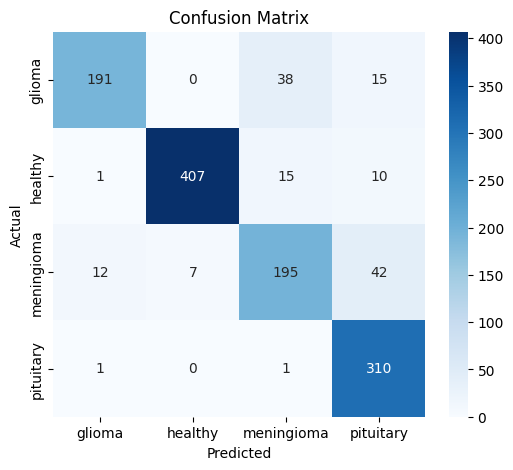

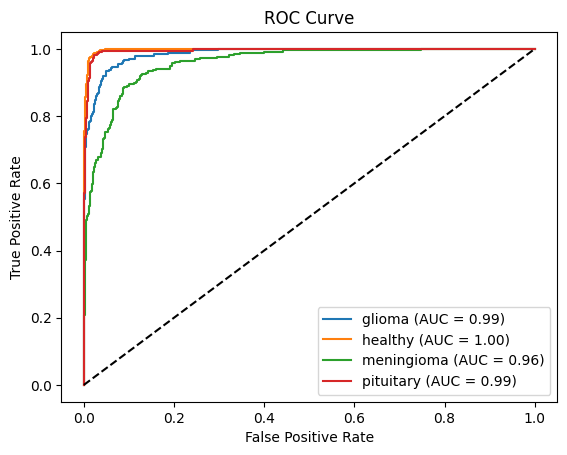

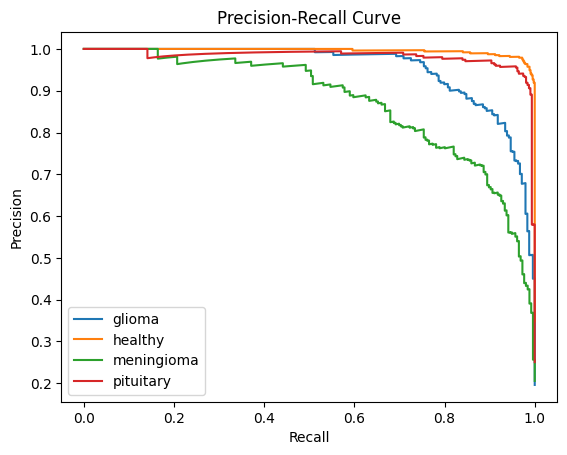

In [26]:
evaluate_model(true_classes, predicted_classes, predictions, list(test_dataset.class_indices.keys()))

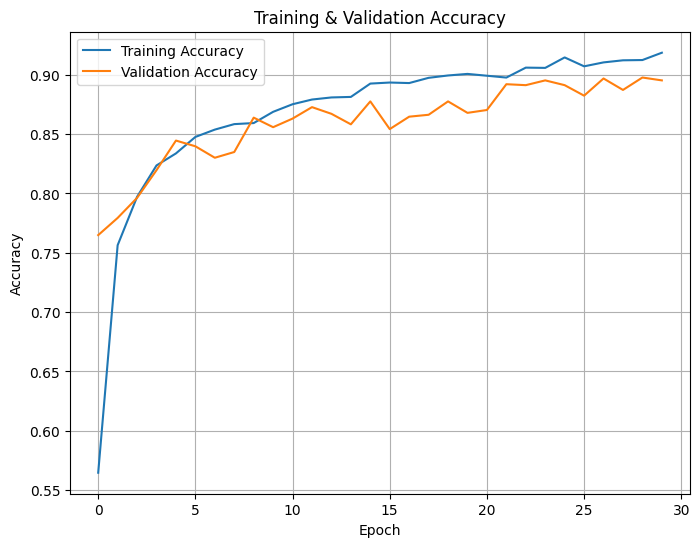

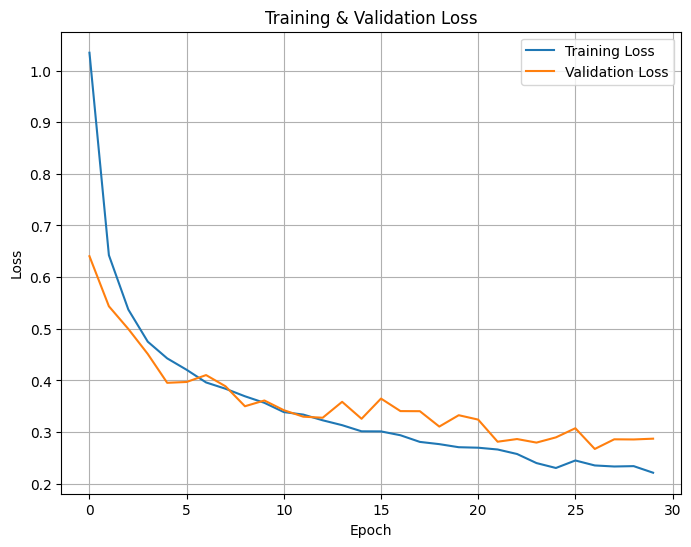

In [27]:
import matplotlib.pyplot as plt


# Plot Accuracy
plt.figure(figsize=(8, 6))
plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(8, 6))
plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()